# Earthdata Cloud Access and PACE Demo

Based on the PACE Hackweek Tutorial started by Anna Windle and Continued by Patrick Gray, slightly modified for SLS and v3.2 by Ivona Cetinic

Modified by Rebekah for IISER TVM Handson

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data.

</div>

[edl]: https://urs.earthdata.nasa.gov/

First - we will explore [NASA Worldview](https://worldview.earthdata.nasa.gov/)
Then - we will figure out all different ways to get [PACE](https://pace.oceansciences.org/access_pace_data.htm) (and other ocean color) data.

All the amazing code to play with PACE data can be found on our [HelpHub](https://nasa.github.io/oceandata-notebooks/index.html). Please explore it after this tutorial.

## 1. Setup

We begin by importing the packages used in this notebook.

This will also install a few packages in case you're working in colab.

In [1]:
pip install earthaccess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 23.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.


In [2]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 37.5 MB/s eta 0:00:00


In [3]:
pip install cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 6.4 MB/s eta 0:00:00


In [4]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import LogNorm
import cmocean

The last import provides a preview of the `DataTree` object. Once it is fully integrated into XArray,
the additional import won't be needed, as the function will be available as `xr.open_datree`.

[back to top](#Contents)

## 2. NASA Earthdata Authentication

Next, we authenticate using our Earthdata Login
credentials. Authentication is not needed to search publicaly
available collections in Earthdata, but is always needed to access
data. We can use the `login` method from the `earthaccess`
package. This will create an authenticated session when we provide a
valid Earthdata Login username and password. The `earthaccess`
package will search for credentials defined by **environmental
variables** or within a **.netrc** file saved in the home
directory. If credentials are not found, an interactive prompt will
allow you to input credentials.

<div class="alert alert-info" role="alert">
    
The `persist=True` argument ensures any discovered credentials are
stored in a `.netrc` file, so the argument is not necessary (but
it's also harmless) for subsequent calls to `earthaccess.login`.

</div>

In [6]:
auth = earthaccess.login(persist=True)

Enter your Earthdata Login username: rshunmugapandi@bigelow.org
Enter your Earthdata password: ··········


[back to top](#Contents)

## 3. Search for Data

Collections on NASA Earthdata are discovered with the
`search_datasets` function, which accepts an `instrument` filter as an
easy way to get started. Each of the items in the list of
collections returned has a "short-name".

In [7]:
results = earthaccess.search_datasets(instrument="oci")

In [8]:
for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_MI_CLOSE
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1B_CLOSE
PACE_OCI_L1B_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_UVAI_UAA_NRT
PACE_OCI_L2_UVAI_UAA
PACE_OCI_L2_AER_UAA_NRT
PACE_OCI_L2_AER_UAA
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_AOP
PACE_OCI_L2_CLOSE
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_CLOUD
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_BGC_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_TRGAS_NRT
PACE_OCI_L2_TRGAS
PACE_OCI_L3B_CLOSE
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3M_UVAI_UAA_NRT
PACE_OCI_L3M_UVAI_UAA
PACE_OCI_L3M_AER_UAA_NRT
PACE_OCI_L3M_AER_UAA
PACE_OCI_L3M_AOP_NRT
PACE_OCI_L3M_AOP
PACE_OCI_L3M_CLOSE
PACE_OCI_L3M_CLOUD_MASK_NRT
PACE_OCI_L3M_CLOUD_MASK
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_KD_NRT
PACE_OCI_L3M_KD
PACE_OCI_L3M_LANDVI_NRT
PACE_OCI_L3M_LANDV

/tmp/ipykernel_1057/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_1057/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_1057/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_1057/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_1057/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` 

<div class="alert alert-info" role="alert">
The short name can also be found on <a href="https://search.earthdata.nasa.gov/search?fi=SPEXone!HARP2!OCI" target="_blank"> Eartdata Search</a>, directly under the collection name, after clicking on the "i" button for a collection in any search result.
</div>

Next, we use the `search_data` function to find granules within a
collection. Let's use the `short_name` for the PACE/OCI Level-2 near real time (NRT), product for biogeochemical properties (although you can
search for granules accross collections too).



The `count` argument limits the number of granules whose metadata is returned and stored in the `results` list.

In [9]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    count=1,
)

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [10]:
results[0]

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:375: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}
/usr/local/lib/python3.12/dist-packages/earthaccess/formatters.py:40: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  granule_size = round(granule.size(), 2)


Collection: {'Version': '3.2', 'ShortName': 'PACE_OCI_L2_BGC_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -68.94215, 'Longitude': -95.68145}, {'Latitude': -60.04733, 'Longitude': -133.52655}, {'Latitude': -68.87811, 'Longitude': 169.0462}, {'Latitude': -84.42067, 'Longitude': 130.41374}, {'Latitude': -68.94215, 'Longitude': -95.68145}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2026-04-01T00:44:53Z', 'BeginningDateTime': '2026-04-01T00:39:58Z'}}
Size(MB): 7.02316951751709
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260401T003958.L2.OC_BGC.V3_2.NRT.nc']

We can refine our search by passing more parameters that describe
the spatiotemporal domain of our use case. Here, we use the
`temporal` parameter to request a date range and the `bounding_box`
parameter to request granules that intersect with a bounding box. We
can even provide a `cloud_cover` threshold to limit files that have
a lower percetnage of cloud cover. We do not provide a `count`, so
we'll get all granules that satisfy the constraints.

Note, bbox is: [Minimum Longitude, Minimum Latitude, Maximum Longitude, Maximum Latitude]

In [11]:
tspan = ("2026-07-11", "2026-07-11")
bbox = (12.200482, 45.287908, 12.539685, 45.621218) #45.287908, 12.539685, 45.621218, 12.200482
clouds = (0, 60)

In [12]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

In [13]:
len(results)

1

In [14]:
results[0]

Collection: {'ShortName': 'PACE_OCI_L2_BGC_NRT', 'Version': '3.2'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 29.59588, 'Longitude': 20.97861}, {'Latitude': 47.41724, 'Longitude': 19.54638}, {'Latitude': 41.45139, 'Longitude': -13.66093}, {'Latitude': 24.29154, 'Longitude': -5.51693}, {'Latitude': 29.59588, 'Longitude': 20.97861}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-07-11T12:08:55Z', 'EndingDateTime': '2026-07-11T12:13:54Z'}}
Size(MB): 15.054804801940918
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260711T120855.L2.OC_BGC.V3_2.NRT.nc']

## 4. Open L2 Data

Let's go ahead and open a couple granules using `xarray`. The `earthaccess.open` function is used when you want to directly read bytes from a remote filesystem, but not download a whole file. When
running code on a host with direct access to the NASA Earthdata
Cloud, you don't need to download the data and `earthaccess.open`
is the way to go.

In [15]:
paths = earthaccess.open(results)

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

The `paths` list contains references to files on a remote filesystem. The ob-cumulus-prod-public is the S3 Bucket in AWS us-west-2 region.

In [16]:
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260711T120855.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu1/wor...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -13.660929
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9675695300102234
    geospatial_bounds:                 POLYGON((-5.51693 24.29154,20.97861 29...

Notice that this `xarray.Dataset` has nothing but "Attributes". The NetCDF data model includes multi-group hierarchies within a single file, where each group maps to an `xarray.Dataset`. The whole file maps to a `DataTree`, which we will only use lightly because the implementation in XArray remains under development.

In [17]:
datatree = open_datatree(paths[0])
datatree

/tmp/ipykernel_1057/995226554.py:1: FutureWarning: In a future version, xarray will not decode the variable 'day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  datatree = open_datatree(paths[0])
/tmp/ipykernel_1057/995226554.py:1: FutureWarning: In a future version, xarray will not decode the variable 'msec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding

<xarray.DataTree>
Group: /
│   Attributes: (12/47)
│       title:                             OCI Level-2 Data BGC
│       product_name:                      PACE_OCI.20260711T120855.L2.OC_BGC.V3_...
│       processing_version:                3.2
│       history:                           l2gen par=/data2/sdpsoper/vdc/vpu1/wor...
│       instrument:                        OCI
│       platform:                          PACE
│       ...                                ...
│       geospatial_lon_min:                -13.660929
│       startDirection:                    Ascending
│       endDirection:                      Ascending
│       day_night_flag:                    Day
│       earth_sun_distance_correction:     0.9675695300102234
│       geospatial_bounds:                 POLYGON((-5.51693 24.29154,20.97861 29...
├── Group: /sensor_band_parameters
│       Dimensions:      (wavelength: 286, number_of_reflective_bands: 286)
│       Coordinates:
│         * wavelength   (wavelength) float64 2kB 315.0 316.0 ... 2.131e+03 2.258e+03
│       Dimensions without coordinates: number_of_reflective_bands
│       Data variables:
│           fwave        (wavelength) float32 1kB ...
│           vcal_gain    (number_of_reflective_bands) float32 1kB ...
│           vcal_offset  (number_of_reflective_bands) float32 1kB ...
│           F0           (number_of_reflective_bands) float32 1kB ...
│           aw           (number_of_reflective_bands) float32 1kB ...
│           bbw          (number_of_reflective_bands) float32 1kB ...
│           k_oz         (number_of_reflective_bands) float32 1kB ...
│           k_no2        (number_of_reflective_bands) float32 1kB ...
│           Tau_r        (number_of_reflective_bands) float32 1kB ...
├── Group: /scan_line_attributes
│       Dimensions:  (number_of_lines: 1710)
│       Dimensions without coordinates: number_of_lines
│       Data variables: (12/13)
│           year     (number_of_lines) float64 14kB ...
│           day      (number_of_lines) timedelta64[ns] 14kB ...
│           msec     (number_of_lines) timedelta64[ns] 14kB ...
│           time     (number_of_lines) datetime64[ns] 14kB ...
│           detnum   (number_of_lines) float32 7kB ...
│           mside    (number_of_lines) float32 7kB ...
│           ...       ...
│           clon     (number_of_lines) float32 7kB ...
│           elon     (number_of_lines) float32 7kB ...
│           slat     (number_of_lines) float32 7kB ...
│           clat     (number_of_lines) float32 7kB ...
│           elat     (number_of_lines) float32 7kB ...
│           csol_z   (number_of_lines) float32 7kB ...
├── Group: /geophysical_data
│       Dimensions:           (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           chlor_a           (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto      (number_of_lines, pixels_per_line) float32 9MB ...
│           pic               (number_of_lines, pixels_per_line) float32 9MB ...
│           poc               (number_of_lines, pixels_per_line) float32 9MB ...
│           chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
│           l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
├── Group: /navigation_data
│       Dimensions:    (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           longitude  (number_of_lines, pixels_per_line) float32 9MB ...
│           latitude   (number_of_lines, pixels_per_line) float32 9MB ...
│           tilt       (number_of_lines) float32 7kB ...
│       Attributes:
│           gringpointlongitude:  [ -5.516928  20.978615  19.546381 -13.660929]
│           gringpointlatitude:   [24.291536 29.595877 47.417236 41.451393]
│           gringpointsequ

In [18]:
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 78MB
Dimensions:           (wavelength: 286, number_of_reflective_bands: 286,
                       number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * wavelength        (wavelength) float64 2kB 315.0 316.0 ... 2.258e+03
Dimensions without coordinates: number_of_reflective_bands, number_of_lines,
                                pixels_per_line
Data variables: (12/32)
    fwave             (wavelength) float32 1kB ...
    vcal_gain         (number_of_reflective_bands) float32 1kB ...
    vcal_offset       (number_of_reflective_bands) float32 1kB ...
    F0                (number_of_reflective_bands) float32 1kB ...
    aw                (number_of_reflective_bands) float32 1kB ...
    bbw               (number_of_reflective_bands) float32 1kB ...
    ...                ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
    longitude         (number_of_lines, pixels_per_line) float32 9MB ...
    latitude          (number_of_lines, pixels_per_line) float32 9MB ...
    tilt              (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260711T120855.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu1/wor...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -13.660929
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9675695300102234
    geospatial_bounds:                 POLYGON((-5.51693 24.29154,20.97861 29...

Here let's play with the raw data with lines as the y axis and pixels as the x axis

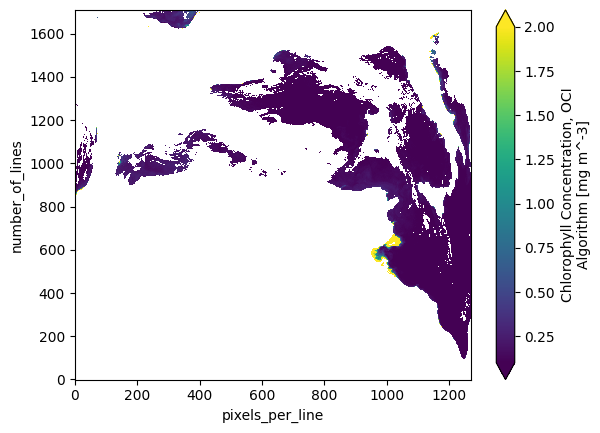

In [19]:
dataset["chlor_a"].plot(cmap="viridis", vmin=.1, vmax=2)
plt.show()

Let's set the coordinates and plot with latitude and longitude so we can project the data onto a grid.

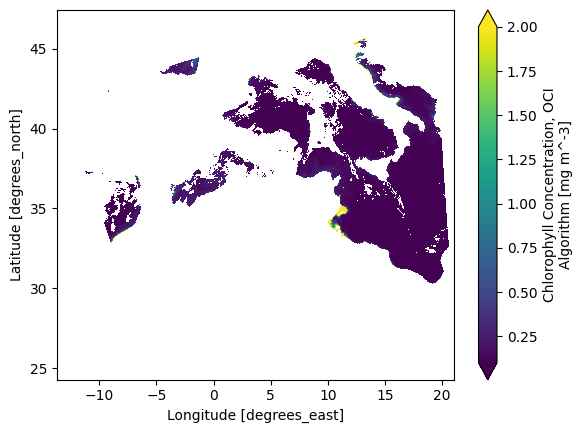

In [20]:
dataset = dataset.set_coords(("longitude", "latitude"))
dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="viridis", vmin=.1, vmax=2)
plt.show()

And if we want to get fancy, we can add the coastline.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


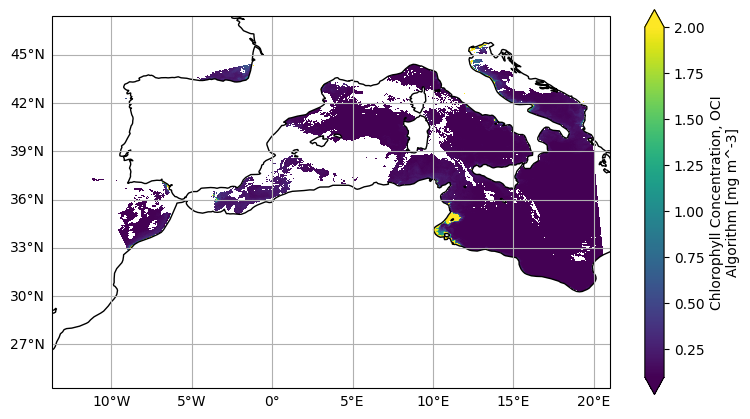

In [21]:
fig = plt.figure(figsize=(9,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="viridis", vmin=0.1, vmax=2, ax=ax)

plt.show()

But really chla is typically lognormally distributed to let's use a log normal scale

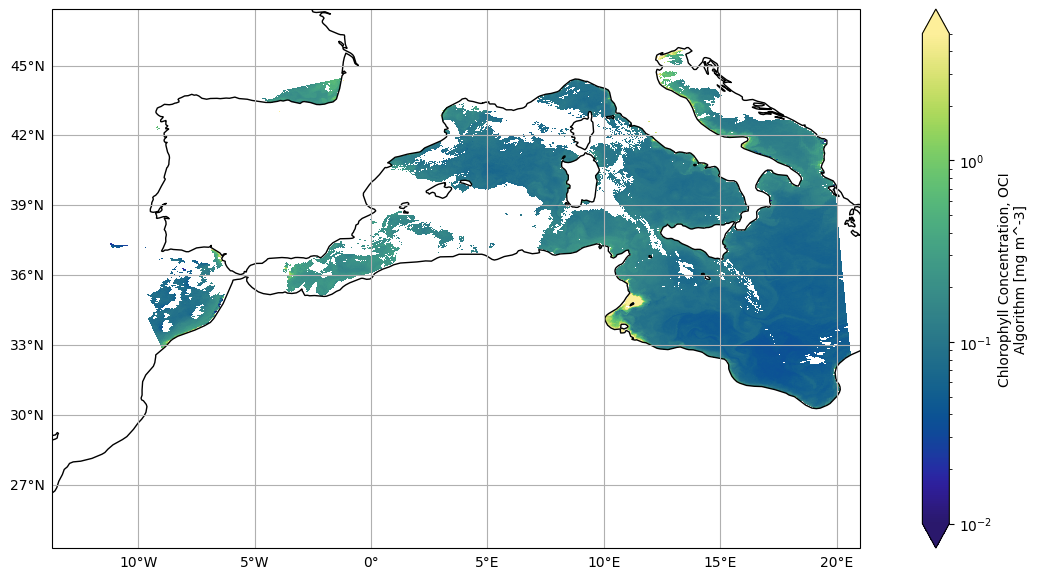

In [22]:
fig = plt.figure(figsize=(16,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = dataset["chlor_a"].plot(x="longitude", y="latitude", cmap=cmocean.cm.haline,norm=LogNorm(vmin=.01, vmax=5), ax=ax)

# ax.set_xlim(12,15)
# ax.set_ylim(42,46)

# plt.savefig('figs/venice_chla.png',dpi=300,transparent=True)

But some of this data may be suspicious so let's check out the flags. They're available in the data here:

In [23]:
dataset.l2_flags

<xarray.DataArray 'l2_flags' (number_of_lines: 1710, pixels_per_line: 1272)> Size: 9MB
[2175120 values with dtype=int32]
Coordinates:
    longitude  (number_of_lines, pixels_per_line) float32 9MB ...
    latitude   (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:      Level-2 Processing Flags
    valid_min:      -2147483648
    valid_max:      2147483647
    flag_masks:     [          1           2           4           8         ...
    flag_meanings:  ATMFAIL LAND PRODWARN HIGLINT HILT HISATZEN COASTZ SPARE ...

And you can inspect all the current flags on https://oceancolor.gsfc.nasa.gov/resources/atbd/ocl2flags/ and they're listed below and put into a python dictionary.

In [25]:
# List l2 flags, then build them into a dict
l2_flags_list = [
    "ATMFAIL", "LAND", "PRODWARN", "HIGLINT", "HILT", "HISATZEN", "COASTZ",
    "SPARE", "STRAYLIGHT", "CLDICE", "COCCOLITH", "TURBIDW", "HISOLZEN",
    "SPARE", "LOWLW", "CHLFAIL", "NAVWARN", "ABSAER", "SPARE", "MAXAERITER",
    "MODGLINT", "CHLWARN", "ATMWARN", "SPARE", "SEAICE", "NAVFAIL", "FILTER",
    "SPARE", "BOWTIEDEL", "HIPOL", "PRODFAIL", "SPARE"]

L2_FLAGS = {flag: 1 << idx for idx, flag in enumerate(l2_flags_list)}

# Bailey and Werdell 2006 exclusion criteria
EXCLUSION_FLAGS = ["LAND", "HIGLINT", "HILT", "STRAYLIGHT", "CLDICE",
                   "ATMFAIL", "LOWLW", "FILTER", "NAVFAIL", "NAVWARN"]

In [26]:
  # Calculate the bitwise OR of all flags in EXCLUSION_FLAGS to get a mask
  exclude_mask = sum(L2_FLAGS[flag] for flag in EXCLUSION_FLAGS)

  # Create a boolean mask
  # True means the flag value does not contain any of the EXCLUSION_FLAGS
  valid_mask = np.bitwise_and(dataset.l2_flags, exclude_mask) == 0

In [27]:
dataset['flag_mask'] = valid_mask

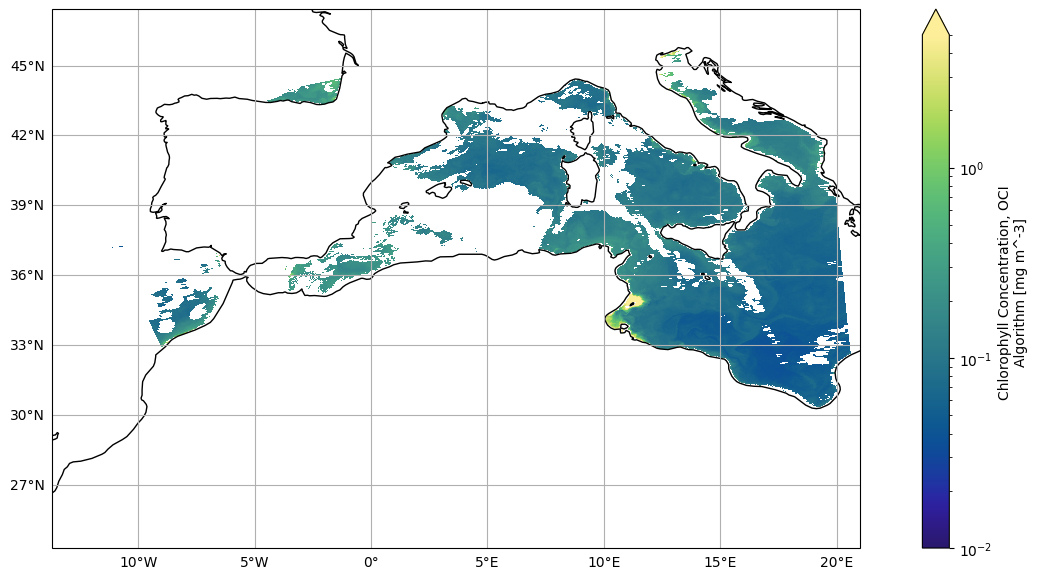

In [28]:
fig = plt.figure(figsize=(16,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = dataset["chlor_a"].where(dataset.flag_mask).plot(x="longitude", y="latitude", cmap=cmocean.cm.haline,norm=LogNorm(vmin=.01, vmax=5), ax=ax)

#ax.set_xlim(12,15)
#ax.set_ylim(42,46)

plt.show()

[back to top](#Contents)

## 5. Open L3M Data

Let's use `earthaccess` to open some L3 mapped IOP granules. We will use a new search filter available in earthaccess.search_data: the granule_name argument accepts strings with the "*" wildcard. We need this to distinguish daily ("DAY") from eight-day ("8D") composites, as well as to get the 0.1 degree resolution projections.

In [29]:
tspan = ("2026-07-07", "2026-07-13")

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_IOP_NRT",
    temporal=tspan,
    granule_name="*.DAY.*.0p1deg.*",
)

paths = earthaccess.open(results)

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

Let's open the first file using `xarray`.

In [33]:
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat          (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon          (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables: (12/59)
    a_400        (lat, lon) float32 26MB ...
    a_413        (lat, lon) float32 26MB ...
    a_425        (lat, lon) float32 26MB ...
    a_442        (lat, lon) float32 26MB ...
    a_460        (lat, lon) float32 26MB ...
    a_475        (lat, lon) float32 26MB ...
    ...           ...
    aph_701      (lat, lon) float32 26MB ...
    adg_442      (lat, lon) float32 26MB ...
    adg_s        (lat, lon) float32 26MB ...
    bbp_442      (lat, lon) float32 26MB ...
    bbp_s        (lat, lon) float32 26MB ...
    palette      (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20260707.L3m.DAY.IOP.V3_2.0p1...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.2
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         656196
    data_minimum:                      -0.7766002
    data_maximum:                      5.498059

Becuase the L3M variables have lat and lon coordinates, it's possible to stack multiple granules along a new dimension that corresponds to time. Instead of xr.open_dataset, we use xr.open_mfdataset to create a single xarray.Dataset (the "mf" in open_mfdataset stands for multiple files) from an array of paths.

The paths list is sorted temporally by default, which means the shape of the paths array specifies the way we need to tile the files together into larger arrays. We specify combine="nested" to combine the files according to the shape of the array of files (or file-like objects), even though paths is not a "nested" list in this case. The concat_dim="date" argument generates a new dimension in the combined dataset, because "date" is not an existing dimension in the individual files.

In [34]:
dataset = xr.open_mfdataset(
    paths,
    combine="nested",
    concat_dim="date",
)
dataset

<xarray.Dataset> Size: 11GB
Dimensions:      (date: 7, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat          (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon          (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: date, rgb, eightbitcolor
Data variables: (12/59)
    a_400        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    a_413        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    a_425        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    a_442        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    a_460        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    a_475        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    ...           ...
    aph_701      (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    adg_442      (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    adg_s        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    bbp_442      (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    bbp_s        (date, lat, lon) float32 181MB dask.array<chunksize=(1, 16, 1024), meta=np.ndarray>
    palette      (date, rgb, eightbitcolor) uint8 5kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20260707.L3m.DAY.IOP.V3_2.0p1...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.2
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         656196
    data_minimum:                      -0.7766002
    data_maximum:                      5.498059

A common reason to generate a single dataset from multiple, daily images is to create a composite. Compare the map from a single day ...

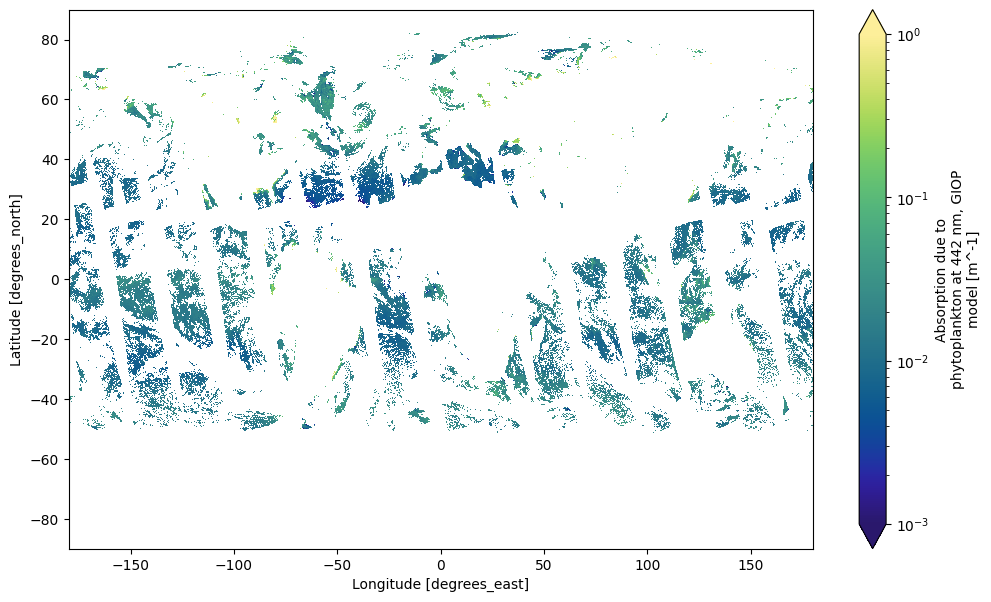

In [32]:
fig, ax = plt.subplots(figsize=(12,7))
dataset["aph_442"].sel({"date": 0}).plot(cmap=cmocean.cm.haline, norm=LogNorm(vmin=.001, vmax=1))
plt.show()

... to a map of average values, skipping "NaN" values that result from clouds.

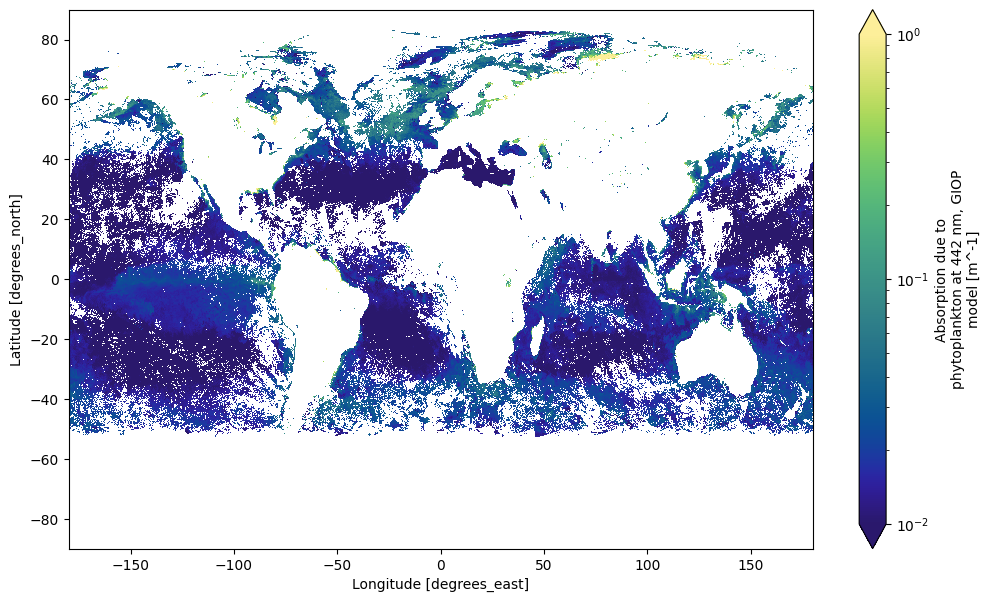

In [35]:
fig, ax = plt.subplots(figsize=(12,7))
dataset["aph_442"].mean("date").plot(cmap=cmocean.cm.haline, norm=LogNorm(vmin=.01, vmax=1))
plt.show()

<div style="background-color: #EDE7F6; padding: 20px; border-radius: 8px; color: #333333;">
Ideas to play with data more:

Can you make this projection a bit more nicer?

Can you plot the other parameters?

Can you plot a measure of variability (standard deviation, variance) of a single parameter?


## 6. Download Data

Let's go ahead and download a couple granules.

Let's look at the `earthaccess.download` function, which is used
to copy files onto a filesystem local to the machine executing the
code. For this function, provide the output of
`earthaccess.search_data` along with a directory where `earthaccess` will store downloaded granules.

Even if you only want to read a slice of the data, and downloading
seems unncessary, if you use `earthaccess.open` while not running on a remote host with direct access to the NASA Earthdata Cloud,
performance will be very poor. This is not a problem with "the
cloud" or with `earthaccess`, it has to do with the data format and may soon be resolved.


In [ ]:

# results = earthaccess.search_data(
#     short_name="PACE_OCI_L2_BGC_NRT",
#     temporal=tspan,
#     bounding_box=bbox,
#     cloud_cover=clouds,
# )

The `paths` list now contains paths to actual files on the local
filesystem.

In [ ]:
# paths = earthaccess.download(results, local_path="data")
# paths

We can open up that locally saved file using `xarray` as well.

In [ ]:
# open_datatree(paths[0])

[back to top](#Contents)

# 7. Now let's look at some spectra

In [ ]:
tspan = ("2026-07-11", "2026-07-11") #date of the field trip
bbox = (12.200482, 45.287908, 12.539685, 45.621218) #45.287908, 12.539685, 45.621218, 12.200482
clouds = (0, 60)

In [ ]:

results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds
)

paths = earthaccess.open(results)

In [ ]:
datatree = xr.open_datatree(paths[-1])
rrs = datatree["geophysical_data"]["Rrs"]
rrs

The Rrs variable has 172 values in the wavelength; the blue, red, and SWIR wavelengths have been combined. Without having to look too closely at the exact wavelength coordinates, we can plot the variable for a blue wavelength using method="nearest".

In [ ]:
plot = rrs.sel({"wavelength": 440}, method="nearest").plot(cmap="viridis", robust=True)

The scene is being plotted using number_of_lines and pixels_per_line as “x” and “y”, respectively. We need to add more coordinates, the latitude and longitude, for a true map. These coordinates variables are in the “navigation_data” group.

Now we often want to grab a specific pixel and inspect the spectra and other attributes

In [ ]:
for item in ("longitude", "latitude"):
    rrs[item] = datatree["navigation_data"][item]
rrs


In [ ]:
rrs_sel = rrs.sel({"wavelength": 440}, method="nearest")
plot = rrs_sel.plot(x="longitude", y="latitude", cmap="viridis", robust=True)

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
im = rrs_sel.plot(x="longitude", y="latitude", cmap="viridis", robust=True, ax=ax)
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
ax.coastlines()
plt.show()

Let’s plot the full “Rrs” spectrum for individual pixels. A visualization with all the pixels wouldn’t be useful, but limiting to a bounding box gives a simple way to subset pixels. Here we define a center lat/lon (Maybe your wisp station), and take 5X5 pixels around it.

In [ ]:
# Define central point
center_lat = 44.05
center_lon = 13.05

# Compute squared distance from every pixel to the center
# (works fine for finding the nearest pixel over a small area)
dist2 = (rrs["latitude"] - center_lat) ** 2 + (rrs["longitude"] - center_lon) ** 2

# Find the index of the closest pixel (in 2D: number_of_lines, pixels_per_line)
min_idx = np.unravel_index(np.nanargmin(dist2.values), dist2.shape)
line_c, pix_c = int(min_idx[0]), int(min_idx[1])


# Define a 5x5 window (2 pixels on each side of the center) you can change this to be 3X3 window
half = 2  # 5x5 box

# Clip to array bounds so we don't go out of range at edges
n_lines = rrs.sizes["number_of_lines"]
n_pix = rrs.sizes["pixels_per_line"]

line_start = max(line_c - half, 0)
line_stop = min(line_c + half + 1, n_lines)   # +1 because slice stop is exclusive
pix_start = max(pix_c - half, 0)
pix_stop = min(pix_c + half + 1, n_pix)

# Select the 5x5 box using integer-position indexing
rrs_box = rrs.isel(
    number_of_lines=slice(line_start, line_stop),
    pixels_per_line=slice(pix_start, pix_stop),
)

print(rrs_box.sizes)

The line plotting method will only draw a line plot for 1D data, which we can get by stacking our two spatial dimensions and choosing to show the new “pixel dimension” in purple, and adding a dark line as an average of Rrs in our selected pixel group.

In [ ]:
# Stack the spatial dimensions into a single "pixel" dimension
rrs_stack = rrs_box.stack(
    {"pixel": ["number_of_lines", "pixels_per_line"]},
    create_index=False,
)

plot = rrs_stack.plot(
    hue="pixel",
    add_legend=False,
    color="plum",
    alpha=0.4,
    linewidth=0.8,
)

rrs_median = rrs_stack.median(dim="pixel", skipna=True)

# Overlay the median as a thick black line
rrs_median.plot(
    color="black",
    linewidth=2.5,
    label="Median Rrs",
)

plt.legend()
plt.tight_layout()
plt.show()

If you want to, now you can export this data for your further analysis (matchup with wisp data from saturday).

In [ ]:

df = rrs_stack.to_dataframe(name="Rrs").reset_index()

# 2. Reshape so each pixel is a row and wavelengths are columns
csv_df = df.pivot(
    index=["pixel", "latitude", "longitude"],
    columns="wavelength",
    values="Rrs"
).reset_index()

# 3. Clean up: Drop the arbitrary pixel index and strip any empty wavelength columns
csv_df = csv_df.drop(columns=["pixel"]).dropna(axis=1, how="all")

# Save to your file
csv_df.to_csv("test_station_only.csv", index=False)



Bravo! You are all done.. lets play more..

Can you explore some other datasets? Can you plot kd to compare it to your secchi depth measurments? But.. Kd might be hiding in a different products suite - go to [PACE data table](https://pace.oceansciences.org/data_table.htm) and see where is it hiding.